# 1.2 风险与波动率

> **这一节讲什么？**  
> 上一节讲了「赚了多少」（收益率）。
> 这一节讲「为了赚这些，你承担了多大的风险」。
>  
> 金融里有句话：**「没有免费的午餐。」**
> 高收益往往伴随高风险。如何量化这个「风险」，就是本节的核心。

## 学习目标
- 理解金融风险的定义与度量方式
- 掌握波动率（Volatility）的计算
- 学会计算夏普比率（Sharpe Ratio）
- 理解最大回撤（Max Drawdown）

In [44]:
import matplotlib.pyplot as plt

# 1. 设置系统自带的中文字体（这里使用黑体 SimHei）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 如果你想用微软雅黑，可以改成 ['Microsoft YaHei']

# 2. 解决更换字体后，负号（-）显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

plt.rcParams['figure.figsize'] = (12, 5)# 全局设置所有 Matplotlib 图表的默认宽度为 12 英寸、高度为 5 英寸。

# 下载数据（AAPL=苹果，TSLA=特斯拉，SPY=标普500指数基金 作为基准）
tickers = ['AAPL', 'SPY', 'TSLA']
data = yf.download(tickers, start='2021-01-01', end='2024-01-01',
                   progress=False)['Close']
returns = data.pct_change().dropna()
print('数据下载完成')
returns.tail(3)

数据下载完成


Ticker,AAPL,SPY,TSLA
Date,,,
2023-12-27,0.000518,0.001808,0.018822
2023-12-28,0.002226,0.000378,-0.031594
2023-12-29,-0.005424,-0.002895,-0.018564


## 1. 波动率（Volatility）

### 为什么用「波动率」来衡量风险？

想象两个同事每个月工资变化：
- A：每月工资 10000 元，基本不变
- B：某月 3000，下月 20000，后月 -5000（亏损）……

B 的「平均工资」可能也是 10000，但你敢把 B 的工资当可靠收入来还房贷吗？当然不敢，因为**波动太大了，不确定性太高**。

**金融里的「风险」 = 收益率的不确定性 = 收益率的波动程度**  
数学上就是收益率的**标准差（Standard Deviation）**：

$$\sigma_{daily} = \text{std}(r_t) \quad \text{（日波动率）}$$

### 为什么要乘 $\sqrt{252}$ 年化？

一年有 252 个交易日，如果每天相互独立，方差会加 252 倍，标准差就要乘 $\sqrt{252}$：

$$\sigma_{annual} = \sigma_{daily} \times \sqrt{252} \quad \text{（年化波动率，方便跨期比较）}$$

日波动率数据：
Ticker
AAPL    0.017511
SPY     0.011085
TSLA    0.037099
dtype: float64
年化波动率数据：
Ticker
AAPL    0.277975
SPY     0.175968
TSLA    0.588926
dtype: float64
年化波动率（越高代表越动荡，风险越大）：
  AAPL  : 27.80%
  SPY   : 17.60%
  TSLA  : 58.89%
滚动波动率：
Ticker          AAPL       SPY      TSLA
Date                                    
2021-01-05       NaN       NaN       NaN
2021-01-06       NaN       NaN       NaN
2021-01-07       NaN       NaN       NaN
2021-01-08       NaN       NaN       NaN
2021-01-11       NaN       NaN       NaN
...              ...       ...       ...
2023-12-22  0.144005  0.094476  0.339685
2023-12-26  0.144498  0.093510  0.342473
2023-12-27  0.144240  0.093380  0.312491
2023-12-28  0.142446  0.092960  0.332976
2023-12-29  0.144101  0.094795  0.334480

[752 rows x 3 columns]


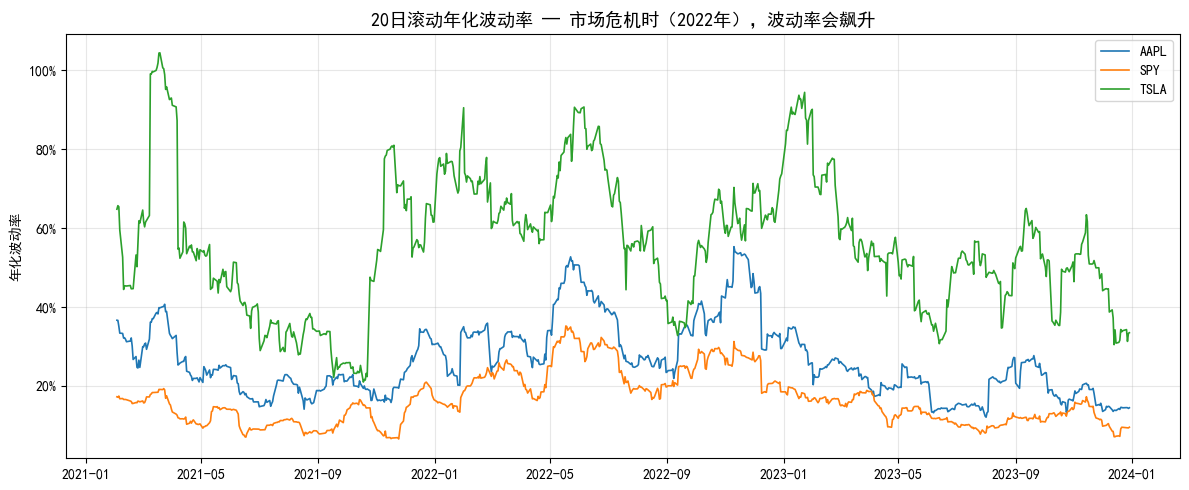

In [47]:
# 计算年化波动率
daily_vol = returns.std()
print(f'日波动率数据：\n{daily_vol}')
annual_vol = daily_vol * np.sqrt(252)
print(f'年化波动率数据：\n{annual_vol}')

print('年化波动率（越高代表越动荡，风险越大）：')
for ticker in tickers:
    print(f'  {ticker:<6}: {annual_vol[ticker]:.2%}')

# 滚动波动率（20日）— 看波动率随时间的变化
rolling_vol = returns.rolling(20).std() * np.sqrt(252)
print(f'滚动波动率：\n{rolling_vol}')

fig, ax = plt.subplots()# 创建1个画布对象fig，生成1个子图对象ax
for ticker in tickers:
    ax.plot(rolling_vol.index, rolling_vol[ticker], label=ticker, linewidth=1.2)
ax.set_title('20日滚动年化波动率 — 市场危机时（2022年），波动率会飙升', fontsize=13)
ax.set_ylabel('年化波动率')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}')) # 把Y轴上的刻度标签，从默认的小数格式改成你想要的百分比格式。
ax.legend()
ax.grid(alpha=0.3) #给图表加上半透明的网格线，提升可读性。
plt.tight_layout()
plt.show()

## 2. 夏普比率（Sharpe Ratio）

### 为什么不能只看收益率？

假设两个策略：
- 策略 A：年化收益 20%，年化波动 10%（收益稳定地涨）
- 策略 B：年化收益 20%，年化波动 60%（大起大落，心跳加速）

两个都赚了 20%，但你愿意用哪个？大多数人选 A，因为同样的收益率，风险小得多。

**夏普比率解决的正是这个问题：单位风险能赚多少「超额」收益。**

$$SR = \frac{\bar{r} - r_f}{\sigma}$$

- $\bar{r}$：策略年化收益率
- $r_f$：**无风险利率**（把钱存银行/买国债的收益，不承担任何风险也能赚到的）
- $\bar{r} - r_f$：**超额收益**（你比「不冒险」多赚的部分）
- $\sigma$：你为这个超额收益承担的风险（波动率）

**夏普比率的解读（经验参考）：**
| 夏普比率 | 解读 |
|---------|------|
| < 0 | 还不如存银行 |
| 0 ~ 0.5 | 勉强 |
| 0.5 ~ 1 | 可以接受 |
| 1 ~ 2 | 良好 |
| > 2 | 优秀（大型基金能做到 1 就已经不错了） |

年化收益率：
Ticker
AAPL    0.177568
SPY     0.115410
TSLA    0.180166
dtype: float64
夏普值：
Ticker
AAPL    0.494893
SPY     0.428545
TSLA    0.238004
dtype: float64

资产       年化收益         年化波动         夏普比率
---------------------------------------------
AAPL         17.76%       27.80%       0.49
SPY          11.54%       17.60%       0.43
TSLA         18.02%       58.89%       0.24


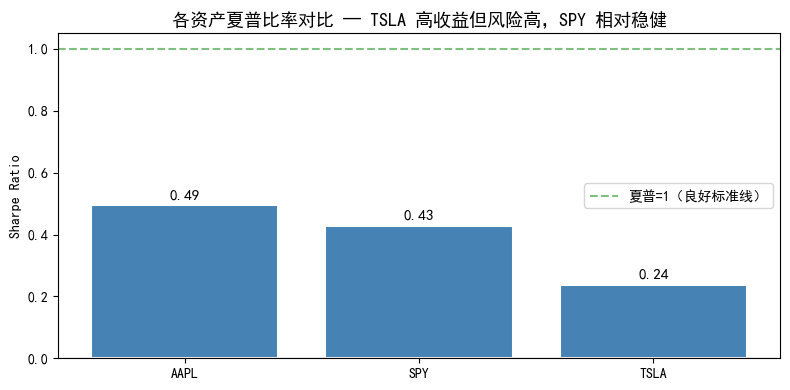

In [ ]:
risk_free_rate = 0.04  # 假设无风险利率 4%（美国国债水平）

annual_ret = returns.mean() * 252 # 把日均收益率，换算成年化收益率
print(f'年化收益率：\n{annual_ret}')
sharpe = (annual_ret - risk_free_rate) / annual_vol
print(f'夏普值：\n{sharpe}')
print(f'\n{"资产":<8} {"年化收益":<12} {"年化波动":<12} {"夏普比率"}')
print('-' * 45)
for ticker in tickers:
    print(f'{ticker:<12} {annual_ret[ticker]:<12.2%} {annual_vol[ticker]:<12.2%} {sharpe[ticker]:.2f}')

# 可视化
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['steelblue' if s > 0 else 'salmon' for s in sharpe.values] #根据sharpe值，给股票分配颜色
bars = ax.bar(tickers, sharpe.values, color=colors, edgecolor='white', linewidth=1.5)
ax.axhline(0, color='black', linewidth=0.8)# 在图表上画一条黑色的水平参考线，标记出“零轴”的位置。
ax.axhline(1, color='green', linestyle='--', alpha=0.5, label='夏普=1（良好标准线）')#图中画个y值是1，表示sharpe状态分界线
ax.set_title('各资产夏普比率对比 — TSLA 高收益但风险高，SPY 相对稳健', fontsize=13)
ax.set_ylabel('Sharpe Ratio')
ax.legend()
for bar, val in zip(bars, sharpe.values): #每根柱子顶上贴数字标签
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f'{val:.2f}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

## 3. 最大回撤（Maximum Drawdown）

### 为什么需要最大回撤？

夏普比率衡量「平均」水平的风险收益比，但有时候平均数会骗人。

想象一个策略：前三年每年赚 30%，然后第四年突然亏了 80%。平均年化收益可能还是正的，但……问题是，在亏 80% 发生之前，你的账户会从高峰跌到谷底，跌了 80%。这个过程让你心理崩溃，你可能早就割肉离场了。

**最大回撤就是衡量这个「最惨烈的连跌」有多深。**

> 从历史某个高点出发，跌到最深的那个谷底，跌了多少百分比？

$$MDD = \max_{t} \left(\frac{\text{峰值} - \text{当前值}}{\text{峰值}}\right)$$

- 最大回撤 < 10%：非常稳健（大型对冲基金的目标）
- 最大回撤 20%~50%：个人可以接受，但要有心理准备
- 最大回撤 > 50%：除非你铁石心肠，否则很难拿住到反弹


回撤数据（越大代表持有体验越痛苦）：
Date
2023-12-01   -0.023922
2023-12-04   -0.033160
2023-12-05   -0.012795
2023-12-06   -0.018410
2023-12-07   -0.008457
2023-12-08   -0.001107
2023-12-11   -0.014020
2023-12-12   -0.006211
2023-12-13    0.000000
2023-12-14    0.000000
2023-12-15   -0.002726
2023-12-18   -0.011206
2023-12-19   -0.005906
2023-12-20   -0.016557
2023-12-21   -0.017314
2023-12-22   -0.022765
2023-12-26   -0.025541
2023-12-27   -0.025037
2023-12-28   -0.022866
2023-12-29   -0.028166
Name: AAPL, dtype: float64

最大回撤值（越大代表持有体验越痛苦）：
-0.3091280797183474
最大回撤发生日期: 2023-01-05 00:00:00

回撤数据（越大代表持有体验越痛苦）：
Date
2023-12-01   -0.417445
2023-12-04   -0.425373
2023-12-05   -0.417713
2023-12-06   -0.416128
2023-12-07   -0.408152
2023-12-08   -0.405225
2023-12-11   -0.415225
2023-12-12   -0.421885
2023-12-13   -0.416323
2023-12-14   -0.387638
2023-12-15   -0.381662
2023-12-18   -0.385126
2023-12-19   -0.372588
2023-12-20   -0.397175
2023-12-21   -0.379223
2023-12-22   -0.384004
2023-12-26   -0.374076
2

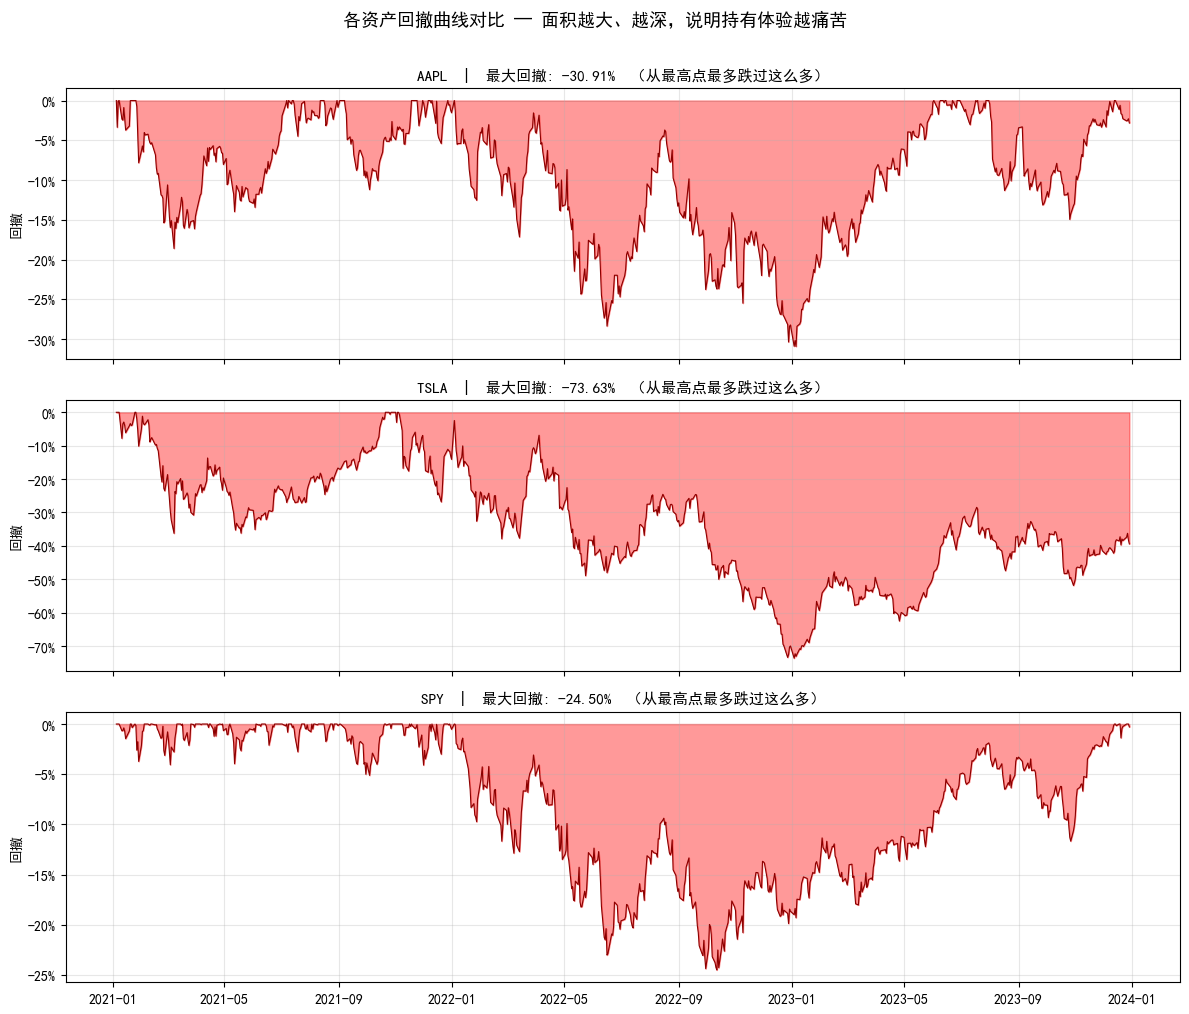

In [35]:
def max_drawdown(returns_series):
    """计算回撤序列和最大回撤"""
    cum_ret = (1 + returns_series).cumprod()      # 累积净值 （连乘）
    rolling_max = cum_ret.cummax()                 # 历史最高点（随时间更新）
    drawdown = (cum_ret - rolling_max) / rolling_max  # 当前离最高点跌了多少
    mdd = drawdown.min()  
    mdd_date =  drawdown.idxmin()  
    return drawdown, mdd, mdd_date

#dd,mdd,mdd_date = max_drawdown(returns[ticker])
#print(f'\n回撤数据（越大代表持有体验越痛苦）：\n{dd.tail(20)}')
#print(f'\n最大回撤（越大代表持有体验越痛苦）：\n{mdd}')
#print(f"发生日期: {mdd_date}")


fig, axes = plt.subplots(len(tickers), 1, figsize=(12, 10), sharex=True)# 子图的行数（你的 tickers 是 ['AAPL', 'TSLA', 'SPY']，所以是 3 行
#sharex=True：所有子图共享同一个 x 轴（缩放/平移时联动），1：子图的列数（只有 1 列）
for ax, ticker in zip(axes, tickers):
    dd,mdd,mdd_date = max_drawdown(returns[ticker])
    print(f'\n回撤数据（越大代表持有体验越痛苦）：\n{dd.tail(20)}')
    print(f'\n最大回撤值（越大代表持有体验越痛苦）：\n{mdd}')
    print(f"最大回撤发生日期: {mdd_date}")
    ax.fill_between(dd.index, dd.values, 0, color='red', alpha=0.4)
    ax.plot(dd.index, dd.values, color='darkred', linewidth=0.8)
    ax.set_title(f'{ticker}  |  最大回撤: {mdd:.2%}  （从最高点最多跌过这么多）', fontsize=11)
    ax.set_ylabel('回撤')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))#格式化 y 轴刻度的
    ax.grid(alpha=0.3)

plt.suptitle('各资产回撤曲线对比 — 面积越大、越深，说明持有体验越痛苦', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 4. 汇总风险指标

把四个核心指标放在一张表里对比，这就是量化评估一个策略/资产时的标准格式：

In [6]:
summary = pd.DataFrame(index=tickers) #创建空表格
summary['年化收益率'] = annual_ret.map('{:.2%}'.format)
summary['年化波动率'] = annual_vol.map('{:.2%}'.format)
summary['夏普比率'] = sharpe.map('{:.2f}'.format)
summary['最大回撤'] = {t: f'{max_drawdown(returns[t])[1]:.2%}' for t in tickers}
summary

,年化收益率,年化波动率,夏普比率,最大回撤
AAPL,17.76%,27.80%,0.49,-30.91%
TSLA,18.02%,58.89%,0.24,-73.63%
SPY,11.54%,17.60%,0.43,-24.50%


## 🎯 练习

1. 增加另一个资产（如债券 ETF `'TLT'`）并对比其风险特征。（债券和股票的风险特征有什么不同？）
2. 计算 2022 年熊市期间（2022-01-01 至 2022-12-31）各资产的最大回撤。
3. **思考题**：波动率高一定是坏事吗？结合夏普比率谈谈——如果波动率翻倍但收益率也翻倍，夏普比率会怎么变？

---
**下一节** → `03_market_basics.ipynb`